# **Oil Price Prediction (Regression)**

---

Predict the close price using LSTM networks with 4 feature configurations:
1. Historical Data
2. Historical + BERT Sentiment
3. Historical + Additional Features
4. Historical + Additional + BERT

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input
from keras.callbacks import EarlyStopping
from pathlib import Path
import glob

import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)


# **Load Data**

---

In [2]:
root_path = Path('/Users/yuepan/Desktop/Campbell-B')

# Load price data from features_merged.csv
combined_data = pd.read_csv(root_path / 'Files/code/data/features_merged.csv')
combined_data.columns = [c.strip().lower() for c in combined_data.columns]
combined_data['date'] = pd.to_datetime(combined_data['date'])
combined_data = combined_data.sort_values('date').reset_index(drop=True)

# Sentiment dataset: Nexus Uni + CrudeBERT merged only
nexus_uni_path = root_path / 'Files/code/final_analysis/Crudebert_results/nexus_uni_crudebert_merged.csv'
Sentiment_Scores = pd.read_csv(nexus_uni_path)
print(f'Loaded {nexus_uni_path.name} ({len(Sentiment_Scores)} rows)')

Sentiment_Scores['date'] = pd.to_datetime(Sentiment_Scores['date'], utc=True, format='mixed').dt.tz_convert(None)
Sentiment_Scores['sentiment'] = Sentiment_Scores['sentiment'].astype(str).str.strip().str.lower()
sentiment_to_score = {'positive': 1, 'neutral': 0, 'negative': -1}
Sentiment_Scores['BERT_compound'] = Sentiment_Scores['sentiment'].map(sentiment_to_score).fillna(0) * Sentiment_Scores['confidence'].fillna(0)
Sentiment_Scores['sentiment'] = Sentiment_Scores['sentiment'].map(sentiment_to_score).fillna(0)
Sentiment_Scores = Sentiment_Scores.drop_duplicates(subset=['date', 'title']).reset_index(drop=True)

print(f'Price data: {combined_data.shape}, {combined_data["date"].min()} to {combined_data["date"].max()}')
print(f'Sentiment data: {Sentiment_Scores.shape}, {Sentiment_Scores["date"].min()} to {Sentiment_Scores["date"].max()}')


Loaded nexus_uni_crudebert_merged.csv (12612 rows)
Price data: (5307, 29), 2005-01-03 00:00:00 to 2026-02-06 00:00:00
Sentiment data: (12612, 6), 2015-01-01 00:00:00 to 2026-04-11 00:00:00


# **Aggregate Daily Sentiment**

---

In [3]:
Sentiment_Scores['date'] = pd.to_datetime(Sentiment_Scores['date']).dt.normalize()
Sentiment_Scores = Sentiment_Scores.sort_values('date')

daily_sentiment = Sentiment_Scores.groupby('date', as_index=False).agg(
    BERT_compound=('BERT_compound', 'mean'),
    sentiment_std=('BERT_compound', 'std'),
    article_count=('BERT_compound', 'count'),
    positive_ratio=('sentiment', lambda x: (x > 0).mean()),
    negative_ratio=('sentiment', lambda x: (x < 0).mean()),
)
daily_sentiment['sentiment_std'] = daily_sentiment['sentiment_std'].fillna(0)

print(daily_sentiment.shape)
print(daily_sentiment.head())
print(f'Unique dates: {daily_sentiment["date"].nunique()}')


(3569, 6)
        date  BERT_compound  sentiment_std  article_count  positive_ratio  \
0 2015-01-01       0.321254       1.131237              3        0.666667   
1 2015-01-03       0.080199       1.043233              4        0.500000   
2 2015-01-05      -0.192157       0.891855              6        0.333333   
3 2015-01-06      -0.362343       0.895803             10        0.300000   
4 2015-01-07      -0.167422       0.867873              6        0.333333   

   negative_ratio  
0        0.333333  
1        0.500000  
2        0.500000  
3        0.700000  
4        0.666667  
Unique dates: 3569


# **Merge Datasets**

---

In [4]:
combined_data['date'] = pd.to_datetime(combined_data['date'])
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'])

merged_df = pd.merge(combined_data, daily_sentiment, on='date', how='left')
merged_df = merged_df.sort_values('date').reset_index(drop=True)

sent_min_date = daily_sentiment['date'].min()
merged_df = merged_df[merged_df['date'] >= sent_min_date].copy().reset_index(drop=True)

merged_df['article_count'] = merged_df['article_count'].fillna(0)
ffill_cols = ['BERT_compound', 'sentiment_std', 'positive_ratio', 'negative_ratio']
merged_df[ffill_cols] = merged_df[ffill_cols].ffill()
merged_df = merged_df.dropna(subset=['BERT_compound']).reset_index(drop=True)

merged_df['bert_roll_3'] = merged_df['BERT_compound'].rolling(3, min_periods=1).mean()
merged_df['bert_roll_7'] = merged_df['BERT_compound'].rolling(7, min_periods=1).mean()
merged_df['bert_momentum'] = merged_df['BERT_compound'] - merged_df['bert_roll_7']
merged_df['sentiment_trend'] = merged_df['bert_roll_3'] - merged_df['bert_roll_7']

# Convert level-based macro features to change-based (avoid out-of-range extrapolation)
if 'cpi_monthly' in merged_df.columns:
    merged_df['cpi_pct'] = merged_df['cpi_monthly'].pct_change().fillna(0)
if 'treasury_yield_10year_daily' in merged_df.columns:
    merged_df['treasury_yield_diff'] = merged_df['treasury_yield_10year_daily'].diff().fillna(0)
if 'fed_funds_daily' in merged_df.columns:
    merged_df['fed_funds_diff'] = merged_df['fed_funds_daily'].diff().fillna(0)
if 'unemployment_rate' in merged_df.columns:
    merged_df['unemployment_diff'] = merged_df['unemployment_rate'].diff().fillna(0)

print(f'merged_df: {merged_df.shape}')
print(f'Date range: {merged_df["date"].min()} to {merged_df["date"].max()}')


merged_df: (2790, 42)
Date range: 2015-01-05 00:00:00 to 2026-02-06 00:00:00


# **Define Feature Sets**

---

In [5]:
# Unified feature sets for 4 models (direct training, no residual correction)
bert_cols = ['bert_roll_3', 'bert_roll_7', 'bert_momentum', 'sentiment_trend', 'article_count']

additional_cols = ['volume', 'ret', 'sma_50', 'rsi_14', 'macd_histogram',
    'treasury_yield_diff', 'fed_funds_diff',
    'sp500_ret', 'vix_close', 'ovx']

feature_sets = {
    'Combined':        ['close'],
    'BERT':            ['close'] + bert_cols,
    'Additional':      ['close'] + additional_cols,
    'Additional+BERT': ['close'] + additional_cols + bert_cols,
}

print('Feature counts:')
for name, f in feature_sets.items():
    print(f'  {name}: {len(f)} features')


Feature counts:
  Combined: 1 features
  BERT: 6 features
  Additional: 11 features
  Additional+BERT: 16 features


# **Prepare Data: Scale, Sequence, Split**

---

In [6]:
# Walk-forward folds (same as classification notebook)
walk_forward_folds = [
    {'train_start': '2015-01-01', 'train_end': '2023-12-31', 'test_start': '2024-01-01', 'test_end': '2024-06-30'},
    {'train_start': '2015-07-01', 'train_end': '2024-06-30', 'test_start': '2024-07-01', 'test_end': '2024-12-31'},
    {'train_start': '2016-01-01', 'train_end': '2024-12-31', 'test_start': '2025-01-01', 'test_end': '2025-06-30'},
    {'train_start': '2016-07-01', 'train_end': '2025-06-30', 'test_start': '2025-07-01', 'test_end': '2025-12-31'},
]

LOOK_BACK = 5

def prepare_fold_data(df, feature_cols, fold, target_col='close', look_back=LOOK_BACK):
    # Target = next-day price change (close.diff()); prediction is recovered as prev_close + change.
    data = df[feature_cols + ['date']].copy()
    data = data.dropna(subset=feature_cols).reset_index(drop=True)
    data['price_change'] = data[target_col].diff()
    data = data.dropna().reset_index(drop=True)

    train_start = pd.Timestamp(fold['train_start'])
    train_end   = pd.Timestamp(fold['train_end'])
    test_start  = pd.Timestamp(fold['test_start'])
    test_end    = pd.Timestamp(fold['test_end'])

    # Fit scalers on training rows only to avoid leakage
    train_mask = (data['date'] >= train_start) & (data['date'] <= train_end)
    x_scaler = MinMaxScaler().fit(data.loc[train_mask, feature_cols].values)
    y_scaler = MinMaxScaler().fit(data.loc[train_mask, ['price_change']].values)

    X_all = x_scaler.transform(data[feature_cols].values)
    y_all = y_scaler.transform(data[['price_change']].values).flatten()
    close_all = data[target_col].values
    dates_all = data['date'].values

    def build(mask_start, mask_end):
        X_seq, y_seq, base_px, actual_px, seq_dates = [], [], [], [], []
        for i in range(look_back, len(data)):
            d = data['date'].iloc[i]
            if d < mask_start or d > mask_end:
                continue
            X_seq.append(X_all[i - look_back:i])
            y_seq.append(y_all[i])
            base_px.append(close_all[i - 1])
            actual_px.append(close_all[i])
            seq_dates.append(dates_all[i])
        return (np.array(X_seq), np.array(y_seq),
                np.array(base_px), np.array(actual_px),
                np.array(seq_dates))

    X_train, y_train, base_train, actual_train, train_dates = build(train_start, train_end)
    X_test,  y_test,  base_test,  actual_test,  test_dates  = build(test_start,  test_end)

    return {
        'X_train': X_train, 'y_train': y_train,
        'X_test':  X_test,  'y_test':  y_test,
        'x_scaler': x_scaler, 'y_scaler': y_scaler,
        'base_prices_train': base_train, 'actual_prices_train': actual_train,
        'base_prices_test':  base_test,  'actual_prices_test':  actual_test,
        'train_dates': train_dates, 'test_dates': test_dates,
    }

fold_data = {}
print(f'Walk-forward folds: {len(walk_forward_folds)}')
for fi, fold in enumerate(walk_forward_folds):
    fold_data[fi] = {}
    print(f'\n  Fold {fi+1}: train {fold["train_start"]} -> {fold["train_end"]}, '
          f'test {fold["test_start"]} -> {fold["test_end"]}')
    for name, cols in feature_sets.items():
        d = prepare_fold_data(merged_df, cols, fold)
        fold_data[fi][name] = d
        print(f'    {name:16s} train={d["X_train"].shape}, test={d["X_test"].shape}')


Walk-forward folds: 4

  Fold 1: train 2015-01-01 -> 2023-12-31, test 2024-01-01 -> 2024-06-30
    Combined         train=(2255, 5, 1), test=(124, 5, 1)
    BERT             train=(2255, 5, 6), test=(124, 5, 6)
    Additional       train=(2255, 5, 11), test=(124, 5, 11)
    Additional+BERT  train=(2255, 5, 16), test=(124, 5, 16)

  Fold 2: train 2015-07-01 -> 2024-06-30, test 2024-07-01 -> 2024-12-31
    Combined         train=(2262, 5, 1), test=(128, 5, 1)
    BERT             train=(2262, 5, 6), test=(128, 5, 6)
    Additional       train=(2262, 5, 11), test=(128, 5, 11)
    Additional+BERT  train=(2262, 5, 16), test=(128, 5, 16)

  Fold 3: train 2016-01-01 -> 2024-12-31, test 2025-01-01 -> 2025-06-30
    Combined         train=(2262, 5, 1), test=(123, 5, 1)
    BERT             train=(2262, 5, 6), test=(123, 5, 6)
    Additional       train=(2262, 5, 11), test=(123, 5, 11)
    Additional+BERT  train=(2262, 5, 16), test=(123, 5, 16)

  Fold 4: train 2016-07-01 -> 2025-06-30, test 202

# **Price Decomposition**

---

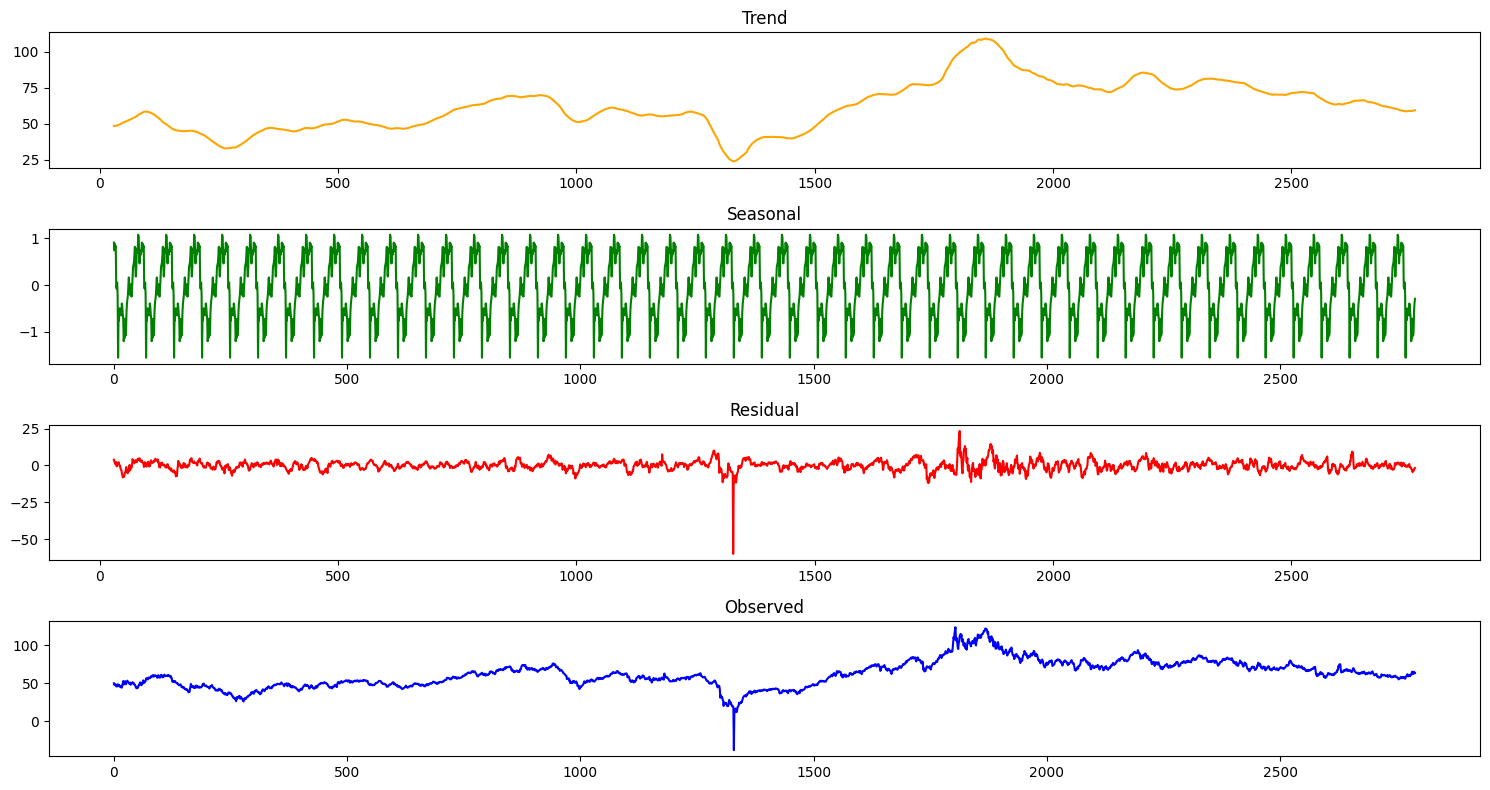

In [7]:
s = sm.tsa.seasonal_decompose(merged_df['close'].dropna().values, period=60)
plt.figure(figsize=(15, 8))
plt.subplot(4, 1, 1)
plt.plot(s.trend, color='orange')
plt.title('Trend')
plt.subplot(4, 1, 2)
plt.plot(s.seasonal, color='green')
plt.title('Seasonal')
plt.subplot(4, 1, 3)
plt.plot(s.resid, color='red')
plt.title('Residual')
plt.subplot(4, 1, 4)
plt.plot(s.observed, color='blue')
plt.title('Observed')
plt.tight_layout()
plt.show()


# **Build and Train LSTM Models**

---

In [8]:
import os, random
from keras.layers import Dropout
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau

SEEDS = [42, 2024, 7]  # 3 seeds per (fold, model); adjust for speed/stability

def reset_seeds(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
    try: tf.keras.utils.set_random_seed(seed)
    except Exception: pass

def build_model(input_shape):
    n_features = input_shape[1]
    if n_features <= 5:
        units_1, units_2, drop, lr = 64, 32, 0.0, 0.001
    elif n_features <= 12:
        units_1, units_2, drop, lr = 128, 64, 0.1, 0.0005
    else:
        units_1, units_2, drop, lr = 256, 128, 0.2, 0.0003
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(LSTM(units_1, return_sequences=True))
    if drop > 0: model.add(Dropout(drop))
    model.add(LSTM(units_2))
    if drop > 0: model.add(Dropout(drop))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=lr, clipnorm=1.0))
    return model

fold_preds = {}
fold_histories = {}

for fi, fold in enumerate(walk_forward_folds):
    print(f'\n{"="*60}')
    print(f'FOLD {fi+1}: train {fold["train_start"]} -> {fold["train_end"]}, '
          f'test {fold["test_start"]} -> {fold["test_end"]}')
    print(f'{"="*60}')
    fold_preds[fi] = {}
    fold_histories[fi] = {}

    for name in feature_sets:
        d = fold_data[fi][name]
        input_shape = (d['X_train'].shape[1], d['X_train'].shape[2])
        bs = 64 if input_shape[1] > 12 else 32

        print(f'\n  Training {name} (features={input_shape[1]}, '
              f'train={d["X_train"].shape[0]}, test={d["X_test"].shape[0]}) '
              f'over {len(SEEDS)} seeds...')

        train_sum = test_sum = None
        last_history = None
        for seed in SEEDS:
            reset_seeds(seed)
            tf.keras.backend.clear_session()
            model = build_model(input_shape)
            history = model.fit(
                d['X_train'], d['y_train'],
                epochs=150, batch_size=bs, shuffle=False,
                validation_data=(d['X_test'], d['y_test']),
                callbacks=[
                    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
                    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
                ],
                verbose=0
            )
            tr_p = model.predict(d['X_train'], verbose=0).flatten()
            te_p = model.predict(d['X_test'],  verbose=0).flatten()
            train_sum = tr_p if train_sum is None else train_sum + tr_p
            test_sum  = te_p if test_sum  is None else test_sum  + te_p
            last_history = history

        fold_preds[fi][name] = {
            'train_scaled': train_sum / len(SEEDS),
            'test_scaled':  test_sum  / len(SEEDS),
        }
        fold_histories[fi][name] = last_history
        val_loss_last = min(last_history.history['val_loss'])
        print(f'    avg train pred shape: {fold_preds[fi][name]["train_scaled"].shape}, '
              f'last-seed best val_loss={val_loss_last:.6f}')

print('\nAll folds trained (multi-seed averaged).')



FOLD 1: train 2015-01-01 -> 2023-12-31, test 2024-01-01 -> 2024-06-30

  Training Combined (features=1, train=2255, test=124) over 3 seeds...
    avg train pred shape: (2255,), last-seed best val_loss=0.000126

  Training BERT (features=6, train=2255, test=124) over 3 seeds...
    avg train pred shape: (2255,), last-seed best val_loss=0.000138

  Training Additional (features=11, train=2255, test=124) over 3 seeds...
    avg train pred shape: (2255,), last-seed best val_loss=0.000212

  Training Additional+BERT (features=16, train=2255, test=124) over 3 seeds...
    avg train pred shape: (2255,), last-seed best val_loss=0.000131

FOLD 2: train 2015-07-01 -> 2024-06-30, test 2024-07-01 -> 2024-12-31

  Training Combined (features=1, train=2262, test=128) over 3 seeds...
    avg train pred shape: (2262,), last-seed best val_loss=0.000220

  Training BERT (features=6, train=2262, test=128) over 3 seeds...
    avg train pred shape: (2262,), last-seed best val_loss=0.000248

  Training Add

# **Evaluate Models**

---

In [15]:
def eval_fold_model(fi, name):
    d = fold_data[fi][name]
    p = fold_preds[fi][name]
    y_scaler = d['y_scaler']
    train_change = y_scaler.inverse_transform(p['train_scaled'].reshape(-1, 1)).flatten()
    test_change  = y_scaler.inverse_transform(p['test_scaled'].reshape(-1, 1)).flatten()
    train_pred = d['base_prices_train'] + train_change
    test_pred  = d['base_prices_test']  + test_change
    y_train = d['actual_prices_train']
    y_test  = d['actual_prices_test']
    rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    mae  = mean_absolute_error(y_test, test_pred)
    mape = np.mean(np.abs((y_test - test_pred) / y_test)) * 100
    return {
        'name': name, 'fold': fi,
        'train_pred': train_pred, 'test_pred': test_pred,
        'y_train': y_train, 'y_test': y_test,
        'train_dates': d['train_dates'], 'test_dates': d['test_dates'],
        'rmse': rmse, 'mae': mae, 'mape': mape,
    }

results = {fi: {name: eval_fold_model(fi, name) for name in feature_sets}
           for fi in range(len(walk_forward_folds))}

all_results = [results[fi][name] for fi in range(len(walk_forward_folds)) for name in feature_sets]
print(f'Evaluated {len(all_results)} (fold x model) combinations.')


Evaluated 16 (fold x model) combinations.


# **Comparison Table**

---

In [16]:
from prettytable import PrettyTable

for fi in range(len(walk_forward_folds)):
    print(f'\n--- Fold {fi+1} Results (seed-averaged) ---')
    t = PrettyTable()
    t.field_names = ['Model', 'RMSE', 'MAE', 'MAPE (%)']
    for name in feature_sets:
        r = results[fi][name]
        t.add_row([name, f'{r["rmse"]:.4f}', f'{r["mae"]:.4f}', f'{r["mape"]:.2f}'])
    print(t)

print(f'\n{"="*60}\nAVERAGE ACROSS ALL FOLDS\n{"="*60}')
avg_t = PrettyTable()
avg_t.field_names = ['Model', 'RMSE', 'MAE', 'MAPE (%)']
for name in feature_sets:
    rmses = [results[fi][name]['rmse'] for fi in range(len(walk_forward_folds))]
    maes  = [results[fi][name]['mae']  for fi in range(len(walk_forward_folds))]
    mapes = [results[fi][name]['mape'] for fi in range(len(walk_forward_folds))]
    avg_t.add_row([
        name,
        f'{np.mean(rmses):.4f} ± {np.std(rmses):.4f}',
        f'{np.mean(maes):.4f} ± {np.std(maes):.4f}',
        f'{np.mean(mapes):.2f} ± {np.std(mapes):.2f}',
    ])
print(avg_t)



--- Fold 1 Results (seed-averaged) ---
+-----------------+--------+--------+----------+
|      Model      |  RMSE  |  MAE   | MAPE (%) |
+-----------------+--------+--------+----------+
|     Combined    | 1.1652 | 0.9450 |   1.21   |
|       BERT      | 1.3291 | 1.0470 |   1.34   |
|    Additional   | 1.3868 | 1.0963 |   1.40   |
| Additional+BERT | 1.1821 | 0.9566 |   1.23   |
+-----------------+--------+--------+----------+

--- Fold 2 Results (seed-averaged) ---
+-----------------+--------+--------+----------+
|      Model      |  RMSE  |  MAE   | MAPE (%) |
+-----------------+--------+--------+----------+
|     Combined    | 1.5394 | 1.2294 |   1.69   |
|       BERT      | 1.6055 | 1.2603 |   1.73   |
|    Additional   | 1.5614 | 1.2412 |   1.70   |
| Additional+BERT | 1.6481 | 1.2928 |   1.78   |
+-----------------+--------+--------+----------+

--- Fold 3 Results (seed-averaged) ---
+-----------------+--------+--------+----------+
|      Model      |  RMSE  |  MAE   | MAPE (%) 

# **Training and Validation Loss**

---

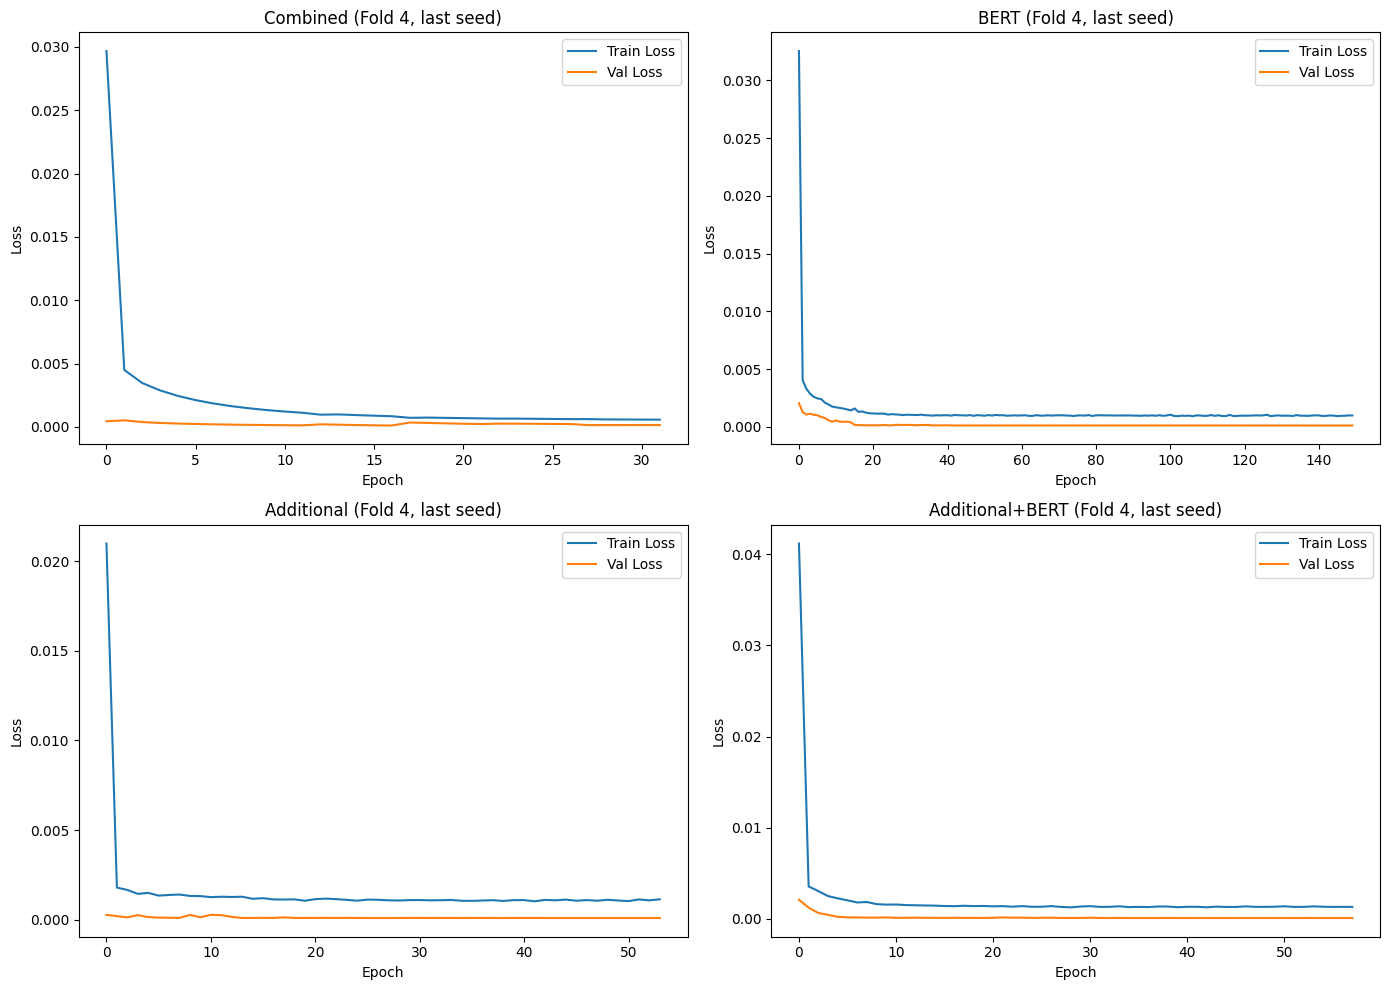

In [17]:
last_fi = len(walk_forward_folds) - 1
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, name in zip(axes.flatten(), feature_sets):
    hist = fold_histories[last_fi][name]
    ax.plot(hist.history['loss'], label='Train Loss')
    ax.plot(hist.history['val_loss'], label='Val Loss')
    ax.set_title(f'{name} (Fold {last_fi+1}, last seed)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
plt.tight_layout(); plt.show()


# **Actual vs Predicted Close Price**

---

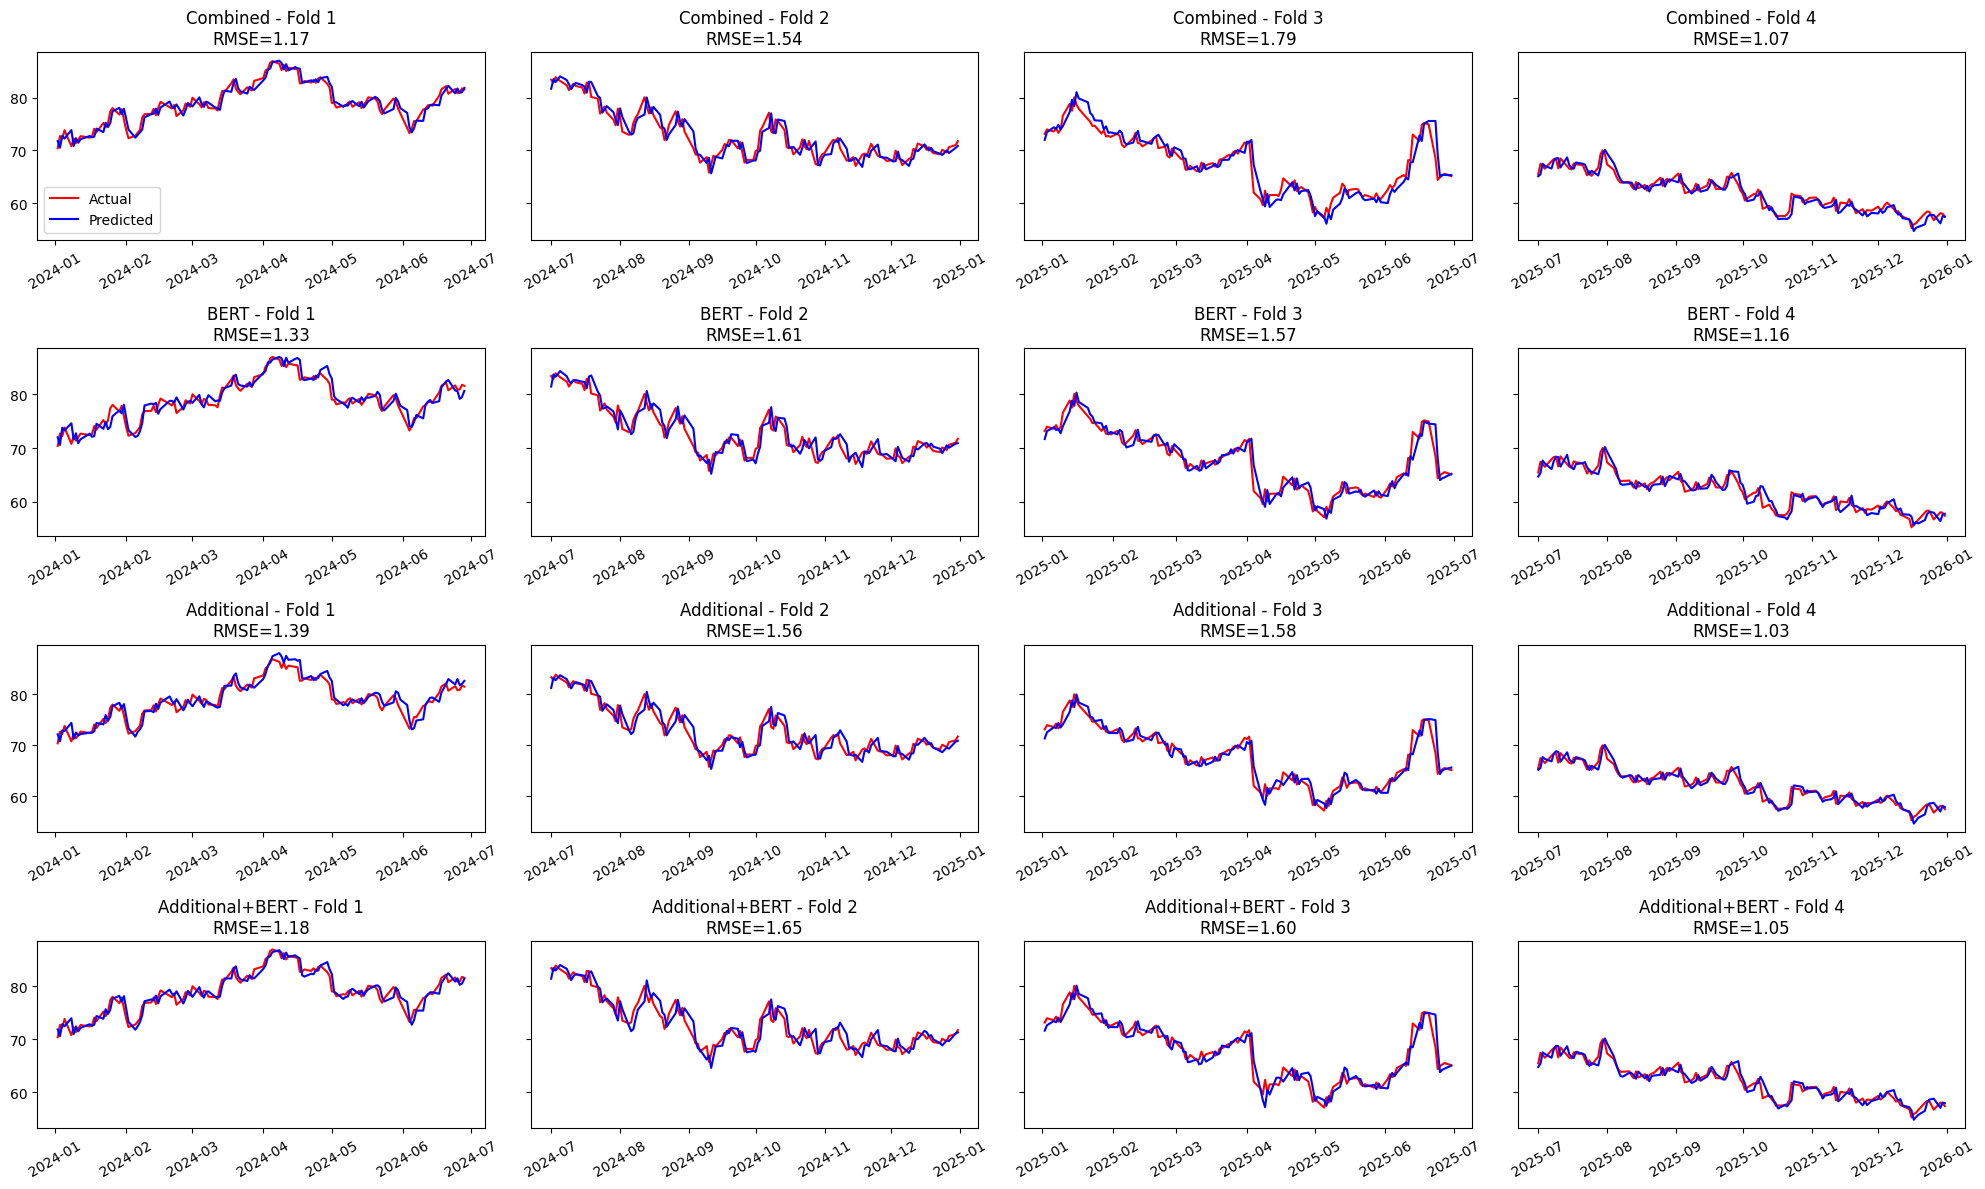

In [18]:
n_folds = len(walk_forward_folds)
fig, axes = plt.subplots(len(feature_sets), n_folds, figsize=(5*n_folds, 3*len(feature_sets)), sharey='row')
for row, name in enumerate(feature_sets):
    for fi in range(n_folds):
        ax = axes[row, fi]
        r = results[fi][name]
        ax.plot(pd.to_datetime(r['test_dates']), r['y_test'], 'r', label='Actual')
        ax.plot(pd.to_datetime(r['test_dates']), r['test_pred'], 'b', label='Predicted')
        ax.set_title(f'{name} - Fold {fi+1}\nRMSE={r["rmse"]:.2f}')
        ax.tick_params(axis='x', rotation=30)
        if row == 0 and fi == 0: ax.legend()
plt.tight_layout(); plt.show()


# **Prediction Error Distribution**

---

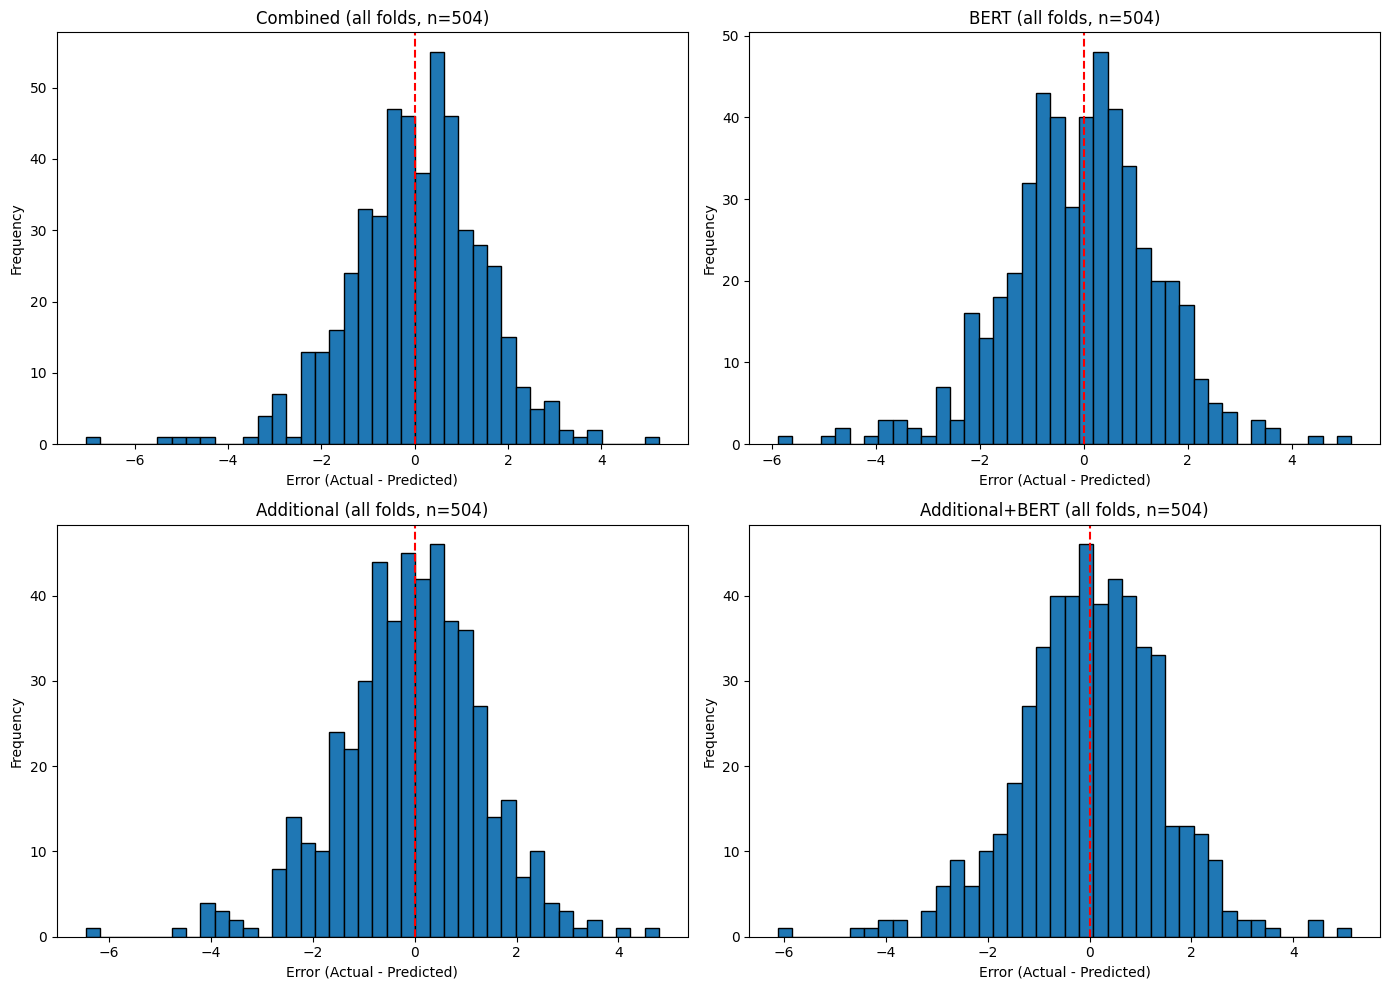

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, name in zip(axes.flatten(), feature_sets):
    errs = np.concatenate([results[fi][name]['y_test'] - results[fi][name]['test_pred']
                            for fi in range(len(walk_forward_folds))])
    ax.hist(errs, bins=40, edgecolor='black')
    ax.set_title(f'{name} (all folds, n={len(errs)})')
    ax.set_xlabel('Error (Actual - Predicted)'); ax.set_ylabel('Frequency')
    ax.axvline(0, color='r', linestyle='--')
plt.tight_layout(); plt.show()


# **Model Performance Comparison**

---

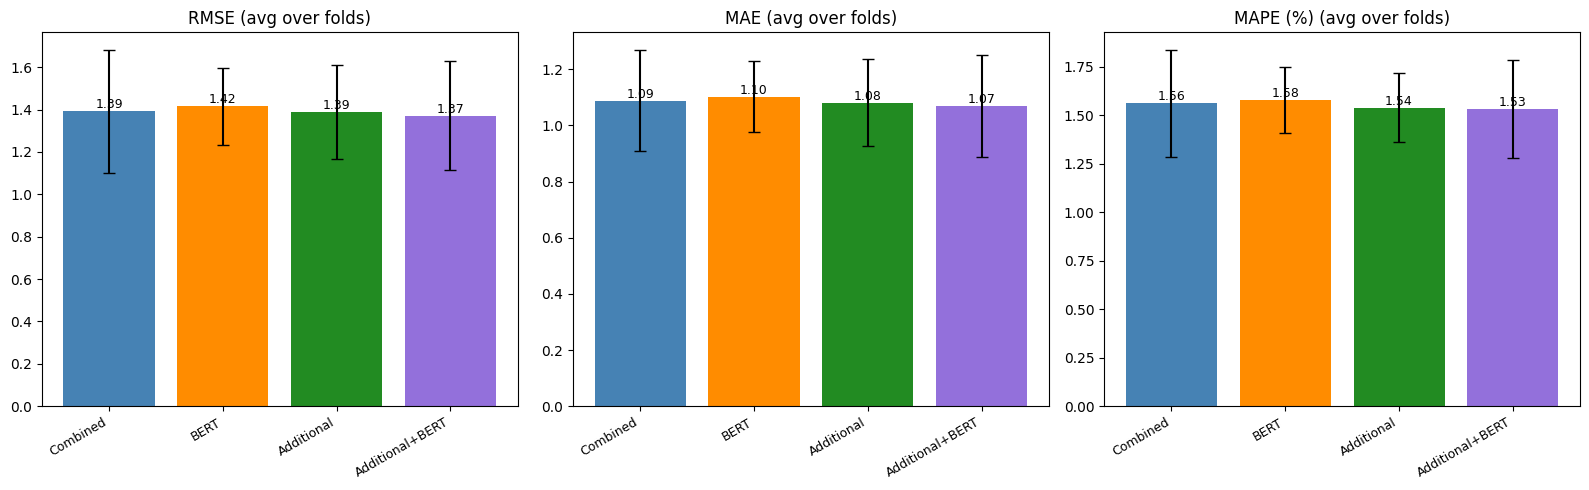

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
names = list(feature_sets.keys())
x = range(len(names))
for ax, metric, label in zip(axes, ['rmse', 'mae', 'mape'], ['RMSE', 'MAE', 'MAPE (%)']):
    vals = [np.mean([results[fi][n][metric] for fi in range(len(walk_forward_folds))]) for n in names]
    errs = [np.std([results[fi][n][metric] for fi in range(len(walk_forward_folds))]) for n in names]
    bars = ax.bar(x, vals, yerr=errs, capsize=4,
                  color=['steelblue', 'darkorange', 'forestgreen', 'mediumpurple'])
    ax.set_title(f'{label} (avg over folds)')
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{v:.2f}',
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()


# **Export Predictions to Excel**

---

Export predicted values, actual values, and dates for each model into separate sheets in one Excel file.

In [21]:
# Export: one Excel per fold, one sheet per model, columns: Date / Actual / Predicted
for fi in range(len(walk_forward_folds)):
    output_path = f'Regression_Fold{fi+1}.xlsx'
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        for name in feature_sets:
            r = results[fi][name]
            df = pd.DataFrame({
                'Date':      pd.to_datetime(r['test_dates']),
                'Actual':    r['y_test'],
                'Predicted': r['test_pred'],
            }).sort_values('Date').reset_index(drop=True)
            df.to_excel(writer, sheet_name=name[:31], index=False)
    print(f'Saved {output_path}')



Saved Regression_Fold1.xlsx
Saved Regression_Fold2.xlsx
Saved Regression_Fold3.xlsx
Saved Regression_Fold4.xlsx
